In [81]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         BÖLÜM 0 — IMPORT & SABİT PARAMETRELER              ║
# ╚══════════════════════════════════════════════════════════════╝

import os
import re
import cv2
import time
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# ── Seed ──────────────────────────────────────────────────────
SEED = 42

os.environ['PYTHONHASHSEED']        = str(SEED)
os.environ['TF_DETERMINISTIC_OPS']  = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Seed: {SEED} — sabitlendi.")

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
from tensorflow.keras.layers import (
    TimeDistributed, LSTM,
    Bidirectional, Dense, Dropout, GlobalAveragePooling2D
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Siniflar ──────────────────────────────────────────────────
CLASSES     = ["Fighting", "Vandalism", "NormalVideos"]
NUM_CLASSES = len(CLASSES)

# ── Goruntu & Sequence Parametreleri ─────────────────────────
IMG_HEIGHT = 64
IMG_WIDTH  = 64
SEQ_LEN    = 30

# ── Egitim Parametreleri ──────────────────────────────────────
BATCH_SIZE  = 4
EPOCHS      = 30
PATIENCE    = 10
TEST_SIZE   = 0.25
FPS_TEST_N  = 10

# ── Dataset Yollari ───────────────────────────────────────────
DATASET_UCF       = "/kaggle/input/datasets/odins0n/ucf-crime-dataset/Train"
DATASET_REAL_LIFE = "/kaggle/input/datasets/mohamedmustafa/real-life-violence-situations-dataset/Real Life Violence Dataset"
DATASET_DCSASS    = "/kaggle/input/datasets/mateohervas/dcsass-dataset/DCSASS Dataset"
DATASET_UCF101    = "/kaggle/input/datasets/abdallahwagih/ucf101-videos/train"

# UCF101 Normal sinifi icin kullanilacak aktiviteler
UCF101_NORMAL = [
    "ShavingBeard", "PlayingCello", "TennisSwing", "CricketShot",
    "WalkingWithDog", "Archery", "BabyCrawling", "BalanceBeam",
    "BandMarching", "Basketball"
]

# ── Dataset Mappingler ────────────────────────────────────────
DCSASS_MAPPING = {
    "Fighting": [
        (DATASET_DCSASS, "Fighting"),
        (DATASET_DCSASS, "Assault"),
        (DATASET_DCSASS, "Abuse"),
        (DATASET_DCSASS, "Shooting"),
    ],
    "Vandalism": [
        (DATASET_DCSASS, "Robbery"),
        (DATASET_DCSASS, "Arson"),
        (DATASET_DCSASS, "Burglary"),
        (DATASET_DCSASS, "Explosion"),
        (DATASET_DCSASS, "Shoplifting"),  # yeni ekle
        (DATASET_DCSASS, "Stealing"),     # yeni ekle
    ],
    "NormalVideos": [],
}

REALLIFE_MAPPING = {
    "Fighting": [
        (DATASET_REAL_LIFE, "Violence"),
    ],
    "Vandalism": [],
    "NormalVideos": [
        (DATASET_REAL_LIFE, "NonViolence"),
    ],
}

# ── Cikti Klasoru ─────────────────────────────────────────────
OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 50)
print(f"  Siniflar          : {CLASSES}")
print(f"  Goruntu boyutu    : {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"  Sequence uzunlugu : {SEQ_LEN} kare")
print(f"  Batch size        : {BATCH_SIZE}")
print(f"  Max epoch         : {EPOCHS}")
print(f"  EarlyStopping     : patience={PATIENCE}")
print(f"  Test orani        : {TEST_SIZE}")
print("=" * 50)

Seed: 42 — sabitlendi.
  Siniflar          : ['Fighting', 'Vandalism', 'NormalVideos']
  Goruntu boyutu    : 64x64
  Sequence uzunlugu : 30 kare
  Batch size        : 4
  Max epoch         : 30
  EarlyStopping     : patience=10
  Test orani        : 0.25


In [82]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         BÖLÜM 1 — VERİ YÜKLEME & ÖN İŞLEME                ║
# ║  Deney 1.1 ve 1.2 için ortak pipeline.                     ║
# ║  Augmentation sadece train setine uygulanır.               ║
# ╚══════════════════════════════════════════════════════════════╝

# ── 1.1 Veri Setini Keşfet ────────────────────────────────────
# Kaç video var, kaç frame var — önce bakalım, sonra yükleyelim.

print("=" * 50)
print("VERİ SETİ ANALİZİ")
print("=" * 50)

for cls in CLASSES:
    path = os.path.join(DATASET_UCF, cls)
    files = sorted(os.listdir(path))

    videos = set()
    for f in files:
        match = re.match(r'(.+)_(\d+)\.png$', f)
        if match:
            videos.add(match.group(1))

    print(f"{cls}:")
    print(f"  Toplam video : {len(videos)}")
    print(f"  Toplam frame : {len(files)}")
print("=" * 50)

VERİ SETİ ANALİZİ
Fighting:
  Toplam video : 45
  Toplam frame : 24684
Vandalism:
  Toplam video : 45
  Toplam frame : 13626
NormalVideos:
  Toplam video : 800
  Toplam frame : 947768


In [83]:
# ── 1.2 Video Gruplarını Oluştur ──────────────────────────────
# Aynı videoya ait frame'leri bir arada tutuyoruz.
# Neden? Train/test split video bazında yapılacak.
# Frame bazında split yapılsaydı aynı videonun kareleri
# hem train'e hem test'e düşerdi → data leakage.

def get_video_groups(class_path, max_videos=30):
    files = sorted(os.listdir(class_path))
    groups = {}
    for f in files:
        match = re.match(r'(.+)_(\d+)\.png$', f)
        if match:
            video_name = match.group(1)
            frame_no   = int(match.group(2))
            if video_name not in groups:
                groups[video_name] = []
            groups[video_name].append((frame_no, f))
    for v in groups:
        groups[v].sort(key=lambda x: x[0])
    return dict(list(groups.items())[:max_videos])

In [84]:
# ── 1.3 Sequence Oluştur ──────────────────────────────────────
# Her videodan tam olarak SEQ_LEN=30 kare seçiyoruz.
# Neden 30? Az seçersen hareket akışını kaçırırsın,
# çok seçersen RAM dolar ve eğitim yavaşlar.
# Strateji: videoyu eşit aralıklara böl, her aralıktan 1 kare al.
# Bu sayede kısa ve uzun videolar aynı boyuta normalize edilir.

def load_sequences(dataset_path, classes, max_videos=30):
    features = []
    labels   = []
    paths    = []

    for class_idx, class_name in enumerate(classes):
        print(f"Yükleniyor: {class_name}")
        class_path   = os.path.join(dataset_path, class_name)
        video_groups = get_video_groups(class_path, max_videos=max_videos)

        for video_name, frame_list in video_groups.items():
            total = len(frame_list)
            if total < SEQ_LEN:
                continue

            # Eşit aralıklı kare seçimi
            step     = max(total // SEQ_LEN, 1)
            selected = frame_list[::step][:SEQ_LEN]
            if len(selected) < SEQ_LEN:
                continue

            sequence = []
            for _, fname in selected:
                img_path = os.path.join(class_path, fname)
                img = cv2.imread(img_path)
                if img is None:
                    break
                img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
                img = img / 255.0   # Normalize: 0-255 → 0-1
                sequence.append(img)

            if len(sequence) == SEQ_LEN:
                features.append(sequence)
                labels.append(class_idx)
                paths.append(video_name)

        print(f"  {len([l for l in labels if l == class_idx])} video yüklendi")

    return np.array(features), np.array(labels), paths


features, labels, paths = load_sequences(DATASET_UCF, CLASSES, max_videos=45)

print(f"\nToplam shape : {features.shape}")
print(f"  → {features.shape[0]} video")
print(f"  → {features.shape[1]} kare/video")
print(f"  → {features.shape[2]}x{features.shape[3]} piksel")
print(f"  → {features.shape[4]} kanal (RGB)")

Yükleniyor: Fighting
  45 video yüklendi
Yükleniyor: Vandalism
  45 video yüklendi
Yükleniyor: NormalVideos
  44 video yüklendi

Toplam shape : (134, 30, 64, 64, 3)
  → 134 video
  → 30 kare/video
  → 64x64 piksel
  → 3 kanal (RGB)


In [85]:
# ── 1.4 Train / Test Ayrımı ───────────────────────────────────
# Split ÖNCE yapılıyor, augmentation SONRA.
# Neden? Test verisi gerçek dünyayı temsil etmeli.
# Augmente edilmiş test verisiyle ölçülen accuracy şişirilmiş olur.

one_hot_labels = to_categorical(labels, num_classes=NUM_CLASSES)

features_train, features_test, labels_train, labels_test = train_test_split(
    features, one_hot_labels,
    test_size=TEST_SIZE,
    shuffle=True,
    random_state=SEED
)

print(f"Train seti : {features_train.shape[0]} video")
print(f"Test seti  : {features_test.shape[0]} video")

Train seti : 100 video
Test seti  : 34 video


In [86]:
# ── 1.5 Augmentation — Sadece Train'e ────────────────────────
# Augmentation: modele aynı videoyu farklı açılardan gösteriyoruz.
# Bu sayede model "sadece bu açıdan kavga böyle görünür" değil,
# "kavga genel olarak böyle görünür" öğreniyor.
# Test setine augmentation UYGULANMAZ.

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    shear_range=10,
    channel_shift_range=20,
    fill_mode='reflect'
)

augmented_sequences = []
for seq_idx, sequence in enumerate(features_train):
    aug_seq = []
    for frame_idx, frame in enumerate(sequence):
        frame_uint8 = (frame * 255).astype(np.uint8)
        np.random.seed(SEED + seq_idx * 100 + frame_idx)  # tekrarlanabilir
        aug_frame = datagen.random_transform(frame_uint8)
        aug_seq.append(aug_frame / 255.0)
    augmented_sequences.append(aug_seq)

# Orijinal + augmented → train seti 2 katına çıkıyor
features_train = np.concatenate([features_train, np.array(augmented_sequences)], axis=0)
labels_train   = np.concatenate([labels_train, labels_train], axis=0)

print(f"Train (augmentation sonrası) : {features_train.shape[0]} video")
print(f"Test (değişmedi)             : {features_test.shape[0]} video")

Train (augmentation sonrası) : 200 video
Test (değişmedi)             : 34 video


In [87]:
# ── BÖLÜM 2 — VERİ YÜKLEME ───────────────────────────────────

def load_sequences(mapping, max_videos_per_source=20):
    features = []
    labels   = []

    for class_idx, (class_name, sources) in enumerate(mapping.items()):
        print(f"\n{'='*40}")
        print(f"Sinif: {class_name} (idx={class_idx})")
        class_count = 0

        if not sources:
            print(f"  Bu sinif icin kaynak yok, atlaniyor.")
            continue

        for base_path, folder_name in sources:
            source_path = os.path.join(base_path, folder_name)

            if not os.path.exists(source_path):
                print(f"  Bulunamadi: {source_path}")
                continue

            items  = sorted(os.listdir(source_path))
            loaded = 0

            for item in items:
                if loaded >= max_videos_per_source:
                    break

                item_path  = os.path.join(source_path, item)
                raw_frames = []

                if os.path.isdir(item_path):
                    klips = sorted([f for f in os.listdir(item_path) if f.endswith('.mp4')])
                    for klip in klips:
                        if loaded >= max_videos_per_source:
                            break
                        klip_path = os.path.join(item_path, klip)
                        cap   = cv2.VideoCapture(klip_path)
                        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                        if total < SEQ_LEN:
                            cap.release()
                            continue
                        indices = np.linspace(0, total - 1, SEQ_LEN, dtype=int)
                        frames  = []
                        for idx in indices:
                            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
                            ret, frm = cap.read()
                            if ret:
                                frm = cv2.resize(frm, (IMG_WIDTH, IMG_HEIGHT))
                                frames.append(frm / 255.0)
                        cap.release()
                        if len(frames) == SEQ_LEN:
                            features.append(frames)
                            labels.append(class_idx)
                            loaded += 1
                    continue

                elif item.endswith(('.mp4', '.avi')):
                    cap   = cv2.VideoCapture(item_path)
                    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                    if total < SEQ_LEN:
                        cap.release()
                        continue
                    indices = np.linspace(0, total - 1, SEQ_LEN, dtype=int)
                    for idx in indices:
                        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
                        ret, frm = cap.read()
                        if ret:
                            frm = cv2.resize(frm, (IMG_WIDTH, IMG_HEIGHT))
                            raw_frames.append(frm / 255.0)
                    cap.release()

                if len(raw_frames) == SEQ_LEN:
                    features.append(raw_frames)
                    labels.append(class_idx)
                    loaded += 1

            print(f"  {folder_name:<20} -> {loaded} video yuklendi")
            class_count += loaded

        print(f"  Toplam {class_name}: {class_count} video")

    return np.array(features), np.array(labels)


def load_ucf_sequences(dataset_path, classes, max_videos=45):
    features = []
    labels   = []

    for class_idx, class_name in enumerate(classes):
        print(f"Yukleniyor: {class_name}")
        class_path   = os.path.join(dataset_path, class_name)
        video_groups = get_video_groups(class_path, max_videos=max_videos)

        for video_name, frame_list in video_groups.items():
            total = len(frame_list)
            if total < SEQ_LEN:
                continue
            step     = max(total // SEQ_LEN, 1)
            selected = frame_list[::step][:SEQ_LEN]
            if len(selected) < SEQ_LEN:
                continue

            sequence = []
            for _, fname in selected:
                img_path = os.path.join(class_path, fname)
                img      = cv2.imread(img_path)
                if img is None:
                    break
                img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
                sequence.append(img / 255.0)

            if len(sequence) == SEQ_LEN:
                features.append(sequence)
                labels.append(class_idx)

        count = sum(1 for l in labels if l == class_idx)
        print(f"  {count} video yuklendi")

    return np.array(features), np.array(labels)


def load_ucf101_normal_sequences(ucf101_path, normal_activities, max_videos=20):
    features  = []
    labels    = []
    class_idx = CLASSES.index("NormalVideos")
    all_files = sorted(os.listdir(ucf101_path))

    for activity in normal_activities:
        activity_files = [f for f in all_files
                          if f.startswith(f"v_{activity}_") and f.endswith('.avi')]
        loaded = 0

        for fname in activity_files:
            if loaded >= max_videos:
                break
            fpath = os.path.join(ucf101_path, fname)
            cap   = cv2.VideoCapture(fpath)
            total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            if total < SEQ_LEN:
                cap.release()
                continue

            indices = np.linspace(0, total - 1, SEQ_LEN, dtype=int)
            frames  = []
            for idx in indices:
                cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
                ret, frm = cap.read()
                if ret:
                    frm = cv2.resize(frm, (IMG_WIDTH, IMG_HEIGHT))
                    frames.append(frm / 255.0)
            cap.release()

            if len(frames) == SEQ_LEN:
                features.append(frames)
                labels.append(class_idx)
                loaded += 1

        print(f"  UCF101 {activity}: {loaded} video yuklendi")

    return np.array(features), np.array(labels)


print("Sequence yukleyiciler hazir.")

Sequence yukleyiciler hazir.


In [88]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         BÖLÜM 3 — VERİ YUKLEME                             ║
# ╚══════════════════════════════════════════════════════════════╝
print("Veri yukleniyor...")
print("=" * 50)

print("\n[1/4] UCF-Crime yukleniyor...")
features_ucf, labels_ucf = load_ucf_sequences(
    DATASET_UCF, CLASSES, max_videos=20
)

print("\n[2/4] DCSASS yukleniyor...")
features_dcsass, labels_dcsass = load_sequences(
    DCSASS_MAPPING, max_videos_per_source=15
)

print("\n[3/4] Real Life Violence yukleniyor...")
features_rlv, labels_rlv = load_sequences(
    REALLIFE_MAPPING, max_videos_per_source=30
)

print("\n[4/4] UCF101 Normal videolar yukleniyor...")
features_ucf101, labels_ucf101 = load_ucf101_normal_sequences(
    DATASET_UCF101, UCF101_NORMAL, max_videos=15
)

features_all = np.concatenate([features_ucf, features_dcsass, features_rlv, features_ucf101], axis=0)
labels_all   = np.concatenate([labels_ucf,   labels_dcsass,   labels_rlv,   labels_ucf101],   axis=0)

print(f"\n{'='*50}")
print(f"Toplam video : {len(features_all)}")
print(f"Shape        : {features_all.shape}")
print(f"Label dagilimi:")
for i, cls in enumerate(CLASSES):
    count = np.sum(labels_all == i)
    print(f"  {cls:<15} : {count} video")
print("=" * 50)

Veri yukleniyor...

[1/4] UCF-Crime yukleniyor...
Yukleniyor: Fighting
  20 video yuklendi
Yukleniyor: Vandalism
  20 video yuklendi
Yukleniyor: NormalVideos
  20 video yuklendi

[2/4] DCSASS yukleniyor...

Sinif: Fighting (idx=0)
  Fighting             -> 15 video yuklendi
  Assault              -> 15 video yuklendi
  Abuse                -> 15 video yuklendi
  Shooting             -> 15 video yuklendi
  Toplam Fighting: 60 video

Sinif: Vandalism (idx=1)
  Robbery              -> 15 video yuklendi
  Arson                -> 15 video yuklendi
  Burglary             -> 15 video yuklendi
  Explosion            -> 15 video yuklendi
  Shoplifting          -> 15 video yuklendi
  Stealing             -> 15 video yuklendi
  Toplam Vandalism: 90 video

Sinif: NormalVideos (idx=2)
  Bu sinif icin kaynak yok, atlaniyor.

[3/4] Real Life Violence yukleniyor...

Sinif: Fighting (idx=0)
  Violence             -> 30 video yuklendi
  Toplam Fighting: 30 video

Sinif: Vandalism (idx=1)
  Bu sinif icin

In [89]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         BÖLÜM 4 — MODEL & EGITIM                           ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Model Mimarisi ────────────────────────────────────────────
def build_mobilenet_bilstm():
    mobilenet = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )
    mobilenet.trainable = False
    for layer in mobilenet.layers[:-30]:
        layer.trainable = False

    model = Sequential([
        TimeDistributed(mobilenet, input_shape=(SEQ_LEN, IMG_HEIGHT, IMG_WIDTH, 3)),
        TimeDistributed(GlobalAveragePooling2D()),
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.5),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        metrics=['accuracy']
    )
    return model

# ── Train / Test / Validation Split ──────────────────────────
one_hot_labels = to_categorical(labels_all, num_classes=NUM_CLASSES)

features_train, features_test, labels_train, labels_test = train_test_split(
    features_all, one_hot_labels,
    test_size=TEST_SIZE,
    shuffle=True,
    random_state=SEED
)
print(f"Train seti : {features_train.shape[0]} video")
print(f"Test seti  : {features_test.shape[0]} video")

# ── Augmentation — sadece train ───────────────────────────────
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=(0.85, 1.15),
    shear_range=8,
    fill_mode='reflect'
)

augmented = []
for seq_idx, sequence in enumerate(features_train):
    aug_seq = []
    for frame_idx, frame in enumerate(sequence):
        frame_uint8 = (frame * 255).astype(np.uint8)
        np.random.seed(SEED + seq_idx * 100 + frame_idx)
        aug_frame = datagen.random_transform(frame_uint8)
        aug_seq.append(aug_frame / 255.0)
    augmented.append(aug_seq)

features_train = np.concatenate([features_train, np.array(augmented)], axis=0)
labels_train   = np.concatenate([labels_train, labels_train], axis=0)
print(f"Train (augmentation sonrasi) : {features_train.shape[0]} video")

# ── Validation Split ──────────────────────────────────────────
features_train, features_val, labels_train, labels_val = train_test_split(
    features_train, labels_train,
    test_size=0.15,
    random_state=SEED
)
print(f"Train (final) : {features_train.shape[0]} video")
print(f"Val           : {features_val.shape[0]} video")
print(f"Test          : {features_test.shape[0]} video")

# ── Class Weights ─────────────────────────────────────────────
y_train_cls = np.argmax(labels_train, axis=1)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_cls),
    y=y_train_cls
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

# ── Model ─────────────────────────────────────────────────────
model = build_mobilenet_bilstm()
print("Model olusturuldu: MobileNetV2 + BiLSTM")

# ── Callbacks ─────────────────────────────────────────────────
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f"{OUTPUT_DIR}/model_best.keras",
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=0.00001,
        verbose=1
    )
]

# ── Egitim ────────────────────────────────────────────────────
print("Egitim basliyor — MobileNetV2 + BiLSTM")
print("=" * 50)
start = time.time()

history = model.fit(
    x=features_train,
    y=labels_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(features_val, labels_val),
    class_weight=class_weight_dict,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

print(f"\nEgitim suresi: {(time.time()-start)/60:.1f} dakika")

Train seti : 247 video
Test seti  : 83 video
Train (augmentation sonrasi) : 494 video
Train (final) : 419 video
Val           : 75 video
Test          : 83 video
Class weights: {0: np.float64(1.0661577608142494), 1: np.float64(0.9835680751173709), 2: np.float64(0.95662100456621)}


/tmp/ipykernel_57/4194565680.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model olusturuldu: MobileNetV2 + BiLSTM
Egitim basliyor — MobileNetV2 + BiLSTM
Epoch 1/30


2026-05-14 22:54:11.693129: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.5347 - loss: 0.9491

2026-05-14 22:56:29.755909: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 1: val_loss improved from inf to 0.42111, saving model to /kaggle/working/model_best.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 172s 537ms/step - accuracy: 0.5360 - loss: 0.9473 - val_accuracy: 0.8400 - val_loss: 0.4211 - learning_rate: 5.0000e-04
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.8966 - loss: 0.3325
Epoch 2: val_loss improved from 0.42111 to 0.29837, saving model to /kaggle/working/model_best.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 26s 247ms/step - accuracy: 0.8968 - loss: 0.3318 - val_accuracy: 0.9067 - val_loss: 0.2984 - learning_rate: 5.0000e-04
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9462 - loss: 0.1389
Epoch 3: val_loss improved from 0.29837 to 0.21703, saving model to /kaggle/working/model_best.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 25s 240ms/step - accuracy: 0.9464 - loss: 0.1386 - val_accuracy: 0.9200 - val_loss: 0.2170 - learning_rate: 5.0000e-04
Epoch 4/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.9906 - loss

In [90]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         BÖLÜM 5 — TAHMIN & METRIKLER                       ║
# ╚══════════════════════════════════════════════════════════════╝

y_pred     = model.predict(features_test, verbose=1)
y_pred_cls = np.argmax(y_pred, axis=1)
y_true     = np.argmax(labels_test, axis=1)

acc  = accuracy_score(y_true, y_pred_cls)
f1   = f1_score(y_true, y_pred_cls, average='weighted')
prec = precision_score(y_true, y_pred_cls, average='weighted')
rec  = recall_score(y_true, y_pred_cls, average='weighted')

model.save(f"{OUTPUT_DIR}/model_final.keras")
size = os.path.getsize(f"{OUTPUT_DIR}/model_final.keras") / (1024 * 1024)

start_fps = time.time()
for s in features_test[:FPS_TEST_N]:
    model.predict(np.expand_dims(s, axis=0), verbose=0)
fps = FPS_TEST_N / (time.time() - start_fps)

print("=" * 50)
print(f"  MobileNetV2 + BiLSTM")
print("=" * 50)
print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  F1 Score  : {f1:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  FPS       : {fps:.2f}")
print(f"  Boyut     : {size:.1f} MB")
print("=" * 50)

2026-05-14 23:03:33.308808: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


3/3 ━━━━━━━━━━━━━━━━━━━━ 69s 16s/step


2026-05-14 23:04:42.886596: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  MobileNetV2 + BiLSTM
  Accuracy  : 0.8795  (87.95%)
  F1 Score  : 0.8787
  Precision : 0.8939
  Recall    : 0.8795
  FPS       : 4.76
  Boyut     : 27.8 MB


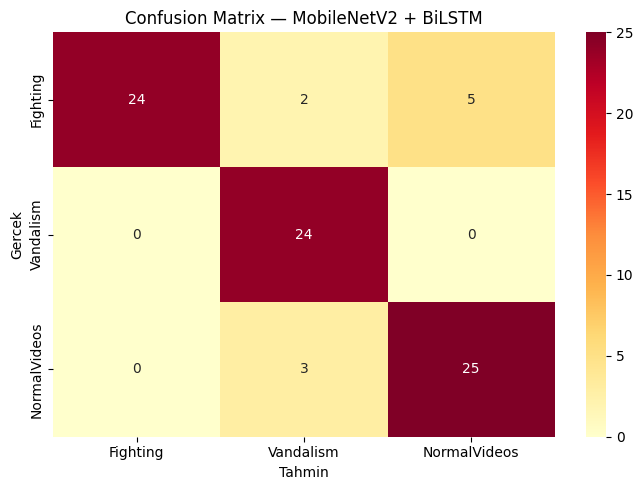

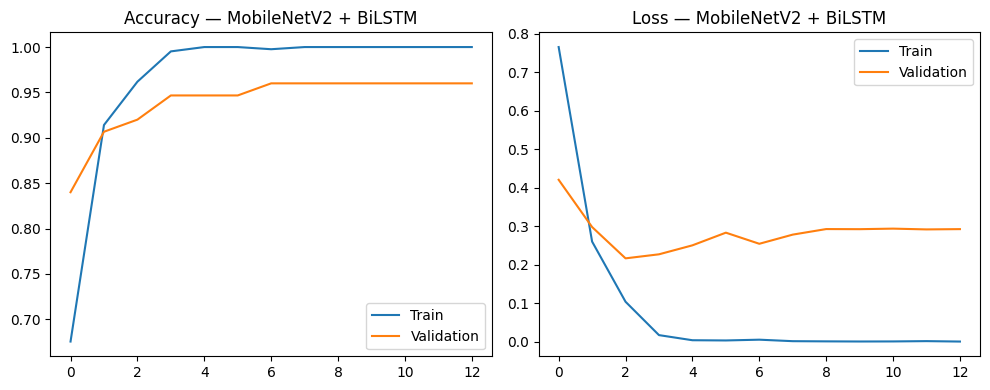

Gorseller kaydedildi: /kaggle/working


In [91]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         BÖLÜM 6 — GORSELLER                                ║
# ╚══════════════════════════════════════════════════════════════╝

cm = confusion_matrix(y_true, y_pred_cls)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — MobileNetV2 + BiLSTM')
plt.ylabel('Gercek')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy — MobileNetV2 + BiLSTM')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss — MobileNetV2 + BiLSTM')
plt.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curve.png', dpi=150)
plt.show()

print(f"Gorseller kaydedildi: {OUTPUT_DIR}")

In [92]:
print(classification_report(y_true, y_pred_cls, target_names=CLASSES))
print(confusion_matrix(y_true, y_pred_cls))

              precision    recall  f1-score   support

    Fighting       1.00      0.77      0.87        31
   Vandalism       0.83      1.00      0.91        24
NormalVideos       0.83      0.89      0.86        28

    accuracy                           0.88        83
   macro avg       0.89      0.89      0.88        83
weighted avg       0.89      0.88      0.88        83

[[24  2  5]
 [ 0 24  0]
 [ 0  3 25]]
